<a href="https://colab.research.google.com/github/MythryeeA/Real-Vs-Fake-News-Detection/blob/main/NM_fake_newsipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Step 1: Load the individual CSV files
true_df = pd.read_csv('/content/True.csv', engine='python', on_bad_lines='skip')
fake_df = pd.read_csv('/content/Fake.csv', engine='python', on_bad_lines='skip')

# Step 2: Add a 'label' column to each dataframe
true_df['label'] = 'TRUE'   # Label all true news
fake_df['label'] = 'FAKE'   # Label all fake news

# Step 3: Combine both dataframes into one
news_df = pd.concat([true_df, fake_df], ignore_index=True)

# Step 4: Save the combined dataframe into a new CSV file
news_df.to_csv('news.csv', index=False)

print("Combined and labeled file saved as news.csv")

Combined and labeled file saved as news.csv


In [ ]:
df=pd.read_csv('/content/news.csv')
df

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",TRUE
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",TRUE
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",TRUE
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",TRUE
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",TRUE
...,...,...,...,...,...
9107,Report: Trump Won’t Be Handling Foreign Or Do...,Donald Trump is officially the Republican nomi...,News,"July 20, 2016",FAKE
9108,Here’s Trump’s Hilariously Illegal Plan To Fo...,Donald Trump has long insisted that he is goin...,News,"July 20, 2016",FAKE
9109,Watch This GOP Delegate CLEARLY Show He Doesn...,If you ve been watching the Republican Nationa...,News,"July 20, 2016",FAKE
9110,Ben Carson Goes Off Teleprompter And Invokes ...,"Tuesday night, retired neurosurgeon and former...",News,"July 20, 2016",FAKE


In [ ]:
df.shape

(9112, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9112 entries, 0 to 9111
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    9112 non-null   object
 1   text     9112 non-null   object
 2   subject  9111 non-null   object
 3   date     9111 non-null   object
 4   label    9112 non-null   object
dtypes: object(5)
memory usage: 356.1+ KB


In [ ]:
df.describe()

,title,text,subject,date,label
count,9112,9112,9111,9111,9112
unique,9093,9096,2,750,2
top,Turkey urges U.S. to review visa suspension as...,WASHINGTON (Reuters) - U.S. President Donald T...,News,"November 30, 2017",FAKE
freq,2,2,5409,45,5409


In [ ]:
df.isnull().sum()

,0
title,0
text,0
subject,1
date,1
label,0


In [ ]:
import pandas as pd
import numpy as np
import re
import string
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# Load the dataset
df = pd.read_csv("news.csv")

# Display basic structure
print("Initial shape:", df.shape)
print("Columns:", df.columns)

# Step 1: Format the 'date' column
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Step 2: Encode the 'label' column (e.g., FAKE -> 0, TRUE -> 1)
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])

# Step 3: Encode the 'subject' column
df['subject_encoded'] = label_encoder.fit_transform(df['subject'])

# Step 4: Define manual stopwords (avoids downloading NLTK resources)
manual_stopwords = {
    'the', 'and', 'is', 'in', 'to', 'of', 'for', 'on', 'with', 'as', 'by',
    'at', 'from', 'that', 'this', 'an', 'it', 'be', 'are', 'was', 'were',
    'or', 'which', 'a', 'but', 'not', 'have', 'has', 'had', 'they', 'their',
    'you', 'i', 'we', 'he', 'she', 'his', 'her', 'them', 'its', 'will', 'would',
    'can', 'could', 'should', 'may', 'might', 'about', 'into', 'over', 'after',
    'before', 'during', 'more', 'most', 'some', 'such', 'no', 'nor', 'only'
}

# Step 5: Define a basic text cleaning function
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    tokens = text.split()
    tokens = [word for word in tokens if word not in manual_stopwords]
    return ' '.join(tokens)

# Step 6: Apply cleaning to 'title' and 'text'
df['clean_title'] = df['title'].apply(clean_text)
df['clean_text'] = df['text'].apply(clean_text)

# Step 7: TF-IDF vectorization on the cleaned text
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['clean_text'])

# Optional: Check outputs
print("TF-IDF matrix shape:", tfidf_matrix.shape)
print(df[['clean_title', 'clean_text', 'subject_encoded', 'label']].head())


Initial shape: (9112, 5)
Columns: Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')
TF-IDF matrix shape: (9112, 5000)
                                         clean_title  \
0  us budget fight looms republicans flip fiscal ...   
1  us military accept transgender recruits monday...   
2  senior us republican senator let mr mueller do...   
3  fbi russia probe helped australian diplomat ti...   
4  trump wants postal service charge much amazon ...   

                                          clean_text  subject_encoded  label  
0  washington reuters head conservative republica...                1      1  
1  washington reuters transgender people allowed ...                1      1  
2  washington reuters special counsel investigati...                1      1  
3  washington reuters trump campaign adviser geor...                1      1  
4  seattlewashington reuters president donald tru...                1      1  


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Define features (X) and target (y)
X = tfidf_matrix
y = df['label']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_log = log_model.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))


=== Logistic Regression ===
Accuracy: 0.9917718047174986
Precision: 0.9904632152588556
Recall: 0.9891156462585035
F1-score: 0.989788972089857
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1088
           1       0.99      0.99      0.99       735

    accuracy                           0.99      1823
   macro avg       0.99      0.99      0.99      1823
weighted avg       0.99      0.99      0.99      1823



In [ ]:
print("Train Accuracy:", log_model.score(X_train, y_train))
print("Test Accuracy:", log_model.score(X_test, y_test))


Train Accuracy: 0.996844560296337
Test Accuracy: 0.9917718047174986


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = tfidf_matrix
y = df['label']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_dt = dt_model.predict(X_test)

print("=== Decision Tree Classifier ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1-score:", f1_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))


=== Decision Tree Classifier ===
Accuracy: 0.9961601755348327
Precision: 0.995945945945946
Recall: 0.9946018893387314
F1-score: 0.9952734638757597

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1082
           1       1.00      0.99      1.00       741

    accuracy                           1.00      1823
   macro avg       1.00      1.00      1.00      1823
weighted avg       1.00      1.00      1.00      1823



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = tfidf_matrix
y = df['label']

# Train-test split (if not already done)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest Classifier ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


=== Random Forest Classifier ===
Accuracy: 0.9994514536478333
Precision: 1.0
Recall: 0.9986504723346828
F1-score: 0.9993247805536799

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1082
           1       1.00      1.00      1.00       741

    accuracy                           1.00      1823
   macro avg       1.00      1.00      1.00      1823
weighted avg       1.00      1.00      1.00      1823



In [ ]:
#saving the model
import joblib
joblib.dump(rf_model, 'random_forest_model.pkl')
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

In [ ]:
#importing necessary dependencies
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import numpy as np
import pandas as pd


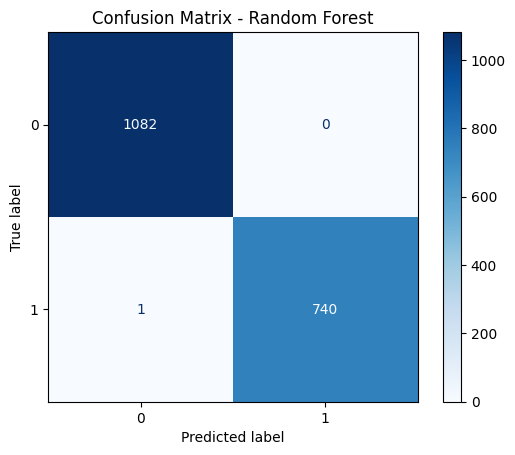

In [ ]:
#Using plots and charts to explain model behavior
#confusion matrix

from sklearn.metrics import ConfusionMatrixDisplay
y_pred_rf = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

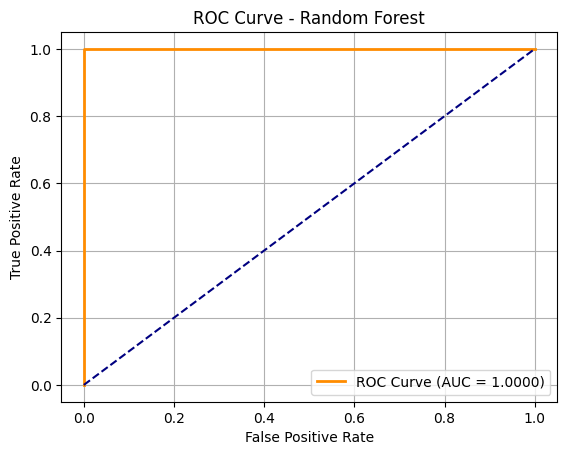

In [ ]:
#ROC curve
from sklearn.metrics import roc_curve, auc
y_probs = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

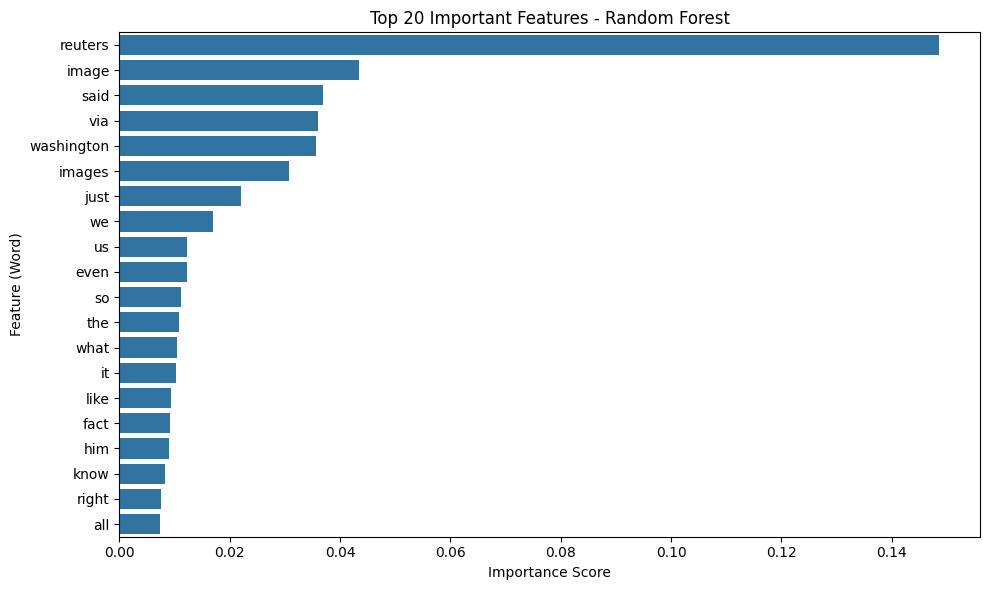

In [ ]:
#Feature Importance Plot
importances = rf_model.feature_importances_
# Corrected the variable name from 'vectorizer' to 'tfidf_vectorizer'
feature_names = tfidf_vectorizer.get_feature_names_out()
# Top 20 important features
indices = np.argsort(importances)[-20:][::-1]
top_features = [feature_names[i] for i in indices]
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=top_features)
plt.title("Top 20 Important Features - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature (Word)")
plt.tight_layout()
plt.show()

<ipython-input-17-a9ae0840a7a4>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=f1_scores, palette="viridis")


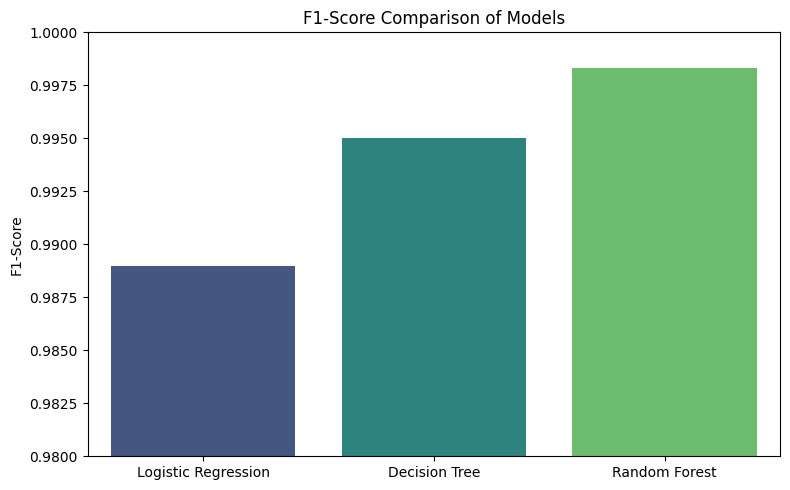

In [ ]:
#Model Performance Comparison (Bar Chart)
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']
f1_scores = [0.9890, 0.9950, 0.9983]
plt.figure(figsize=(8, 5))
sns.barplot(x=model_names, y=f1_scores, palette="viridis")
plt.title("F1-Score Comparison of Models")
plt.ylabel("F1-Score")
plt.ylim(0.98, 1.0)
plt.tight_layout()
plt.show()

In [ ]:
# Print Top 10 Features with highest importance
for i in range(10):
    print(f"{i+1}. {top_features[i]} - Importance Score: {importances[indices[i]]:.4f}")

1. reuters - Importance Score: 0.1486
2. image - Importance Score: 0.0433
3. said - Importance Score: 0.0369
4. via - Importance Score: 0.0360
5. washington - Importance Score: 0.0356
6. images - Importance Score: 0.0307
7. just - Importance Score: 0.0221
8. we - Importance Score: 0.0170
9. us - Importance Score: 0.0123
10. even - Importance Score: 0.0122


**Exploratory Data Analysis(EDA)**

<ipython-input-19-e2f128baccb4>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='coolwarm')


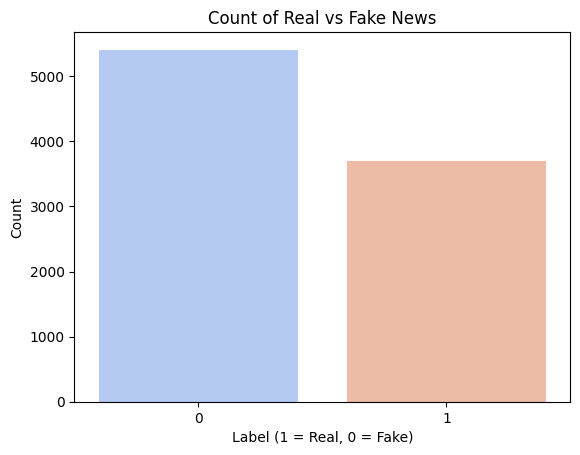

In [ ]:
# 1. Univariate Analysis:
#a) Target Variable Distribution
# Distribution of real vs fake
sns.countplot(data=df, x='label', palette='coolwarm')
plt.title('Count of Real vs Fake News')
plt.xlabel('Label (1 = Real, 0 = Fake)')
plt.ylabel('Count')
plt.show()

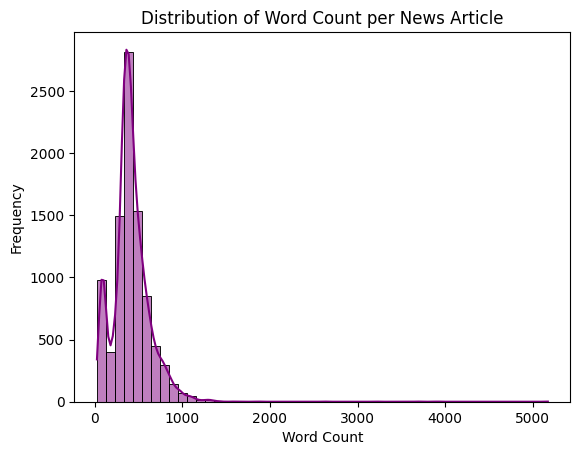

In [ ]:
#b) Word Count per Article
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
sns.histplot(df['word_count'], bins=50, kde=True, color='purple')
plt.title('Distribution of Word Count per News Article')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

<ipython-input-21-3d1d4d43d846>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='word_count', palette='Set2')


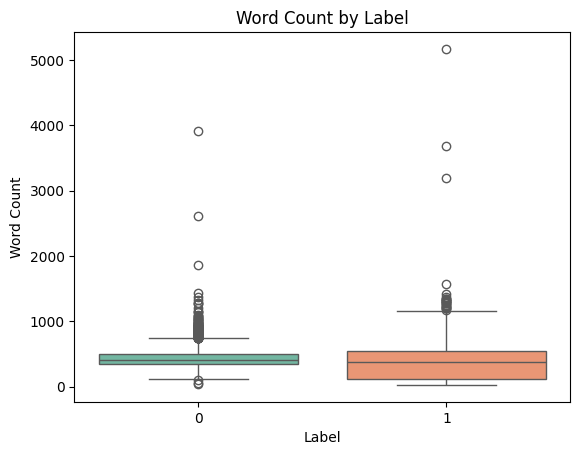

In [ ]:
#c) Boxplot of Word Count
sns.boxplot(data=df, x='label', y='word_count', palette='Set2')
plt.title('Word Count by Label')
plt.xlabel('Label')
plt.ylabel('Word Count')
plt.show()

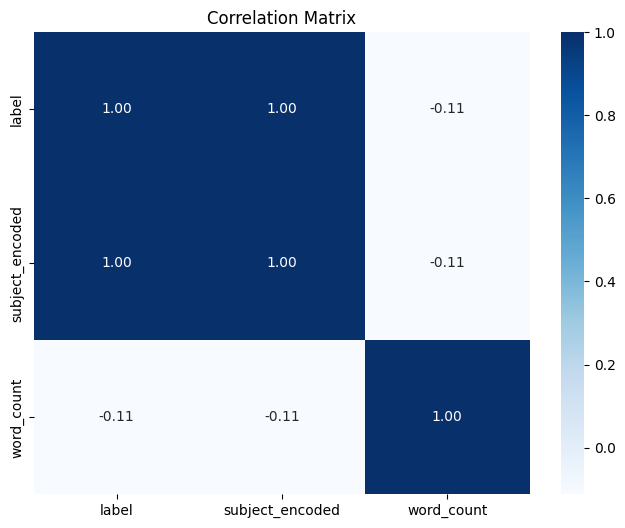

In [ ]:
#2. Bivariate / Multivariate Analysis
#a) Correlation Matrix (Numerical features)
# For numerical features
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [ ]:
import pandas as pd

# Example DataFrame: `df` should already have the following
# clean_text, label (0 = FAKE, 1 = REAL), predicted_label (optional), subject_encoded

export_df = df[['clean_text', 'label', 'subject_encoded']]
export_df.to_csv('fake_news_visualization_data.csv', index=False)


In [ ]:
df.head()

,title,text,subject,date,label,subject_encoded,clean_title,clean_text,word_count
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,2017-12-31,1,6,us budget fight looms republicans flip fiscal ...,washington reuters head conservative republica...,749
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,2017-12-29,1,6,us military accept transgender recruits monday...,washington reuters transgender people allowed ...,624
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,2017-12-31,1,6,senior us republican senator let mr mueller do...,washington reuters special counsel investigati...,457
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,2017-12-30,1,6,fbi russia probe helped australian diplomat ti...,washington reuters trump campaign adviser geor...,376
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,2017-12-29,1,6,trump wants postal service charge much amazon ...,seattlewashington reuters president donald tru...,852
